# Finch regularization benchmarks

This notebook compares `specialize=false` (generic Finch codegen) against `specialize=true`
(data-aware, regularity-mined codegen) for SpMV and SpMM across several sparsity patterns.

Notebook structure:
1. Activate the benchmark environment.
2. Verify that specialization changes generated code for representative patterns.
3. Build one benchmark suite covering all cases.
4. Run the suite once.
5. Print CSV tables and plot one figure for SpMV and one for SpMM.

Patterns in the suite:
- contiguous
- banded
- identical-relative
- mixed
- random

All benchmarks use `evals=1` because the kernels mutate their outputs in place.

In [1]:
using Pkg

proj_root = isdir(joinpath(pwd(), "benchmark")) ? pwd() : dirname(pwd())
Pkg.activate(joinpath(proj_root, "benchmark"))
Pkg.develop(PackageSpec(path=proj_root))
Pkg.instantiate()

using Finch
using BenchmarkTools
using Random
using Printf
using Plots

Random.seed!(42);

  Activating project at `~/Sparse-Tensor-Specialization/Finch.jl/benchmark`
   Resolving package versions...
     Project No packages added to or removed from `~/Sparse-Tensor-Specialization/Finch.jl/benchmark/Project.toml`
    Manifest No packages added to or removed from `~/Sparse-Tensor-Specialization/Finch.jl/benchmark/Manifest.toml`
Precompiling packages...
  81506.5 ms  ✓ Finch
   1710.6 ms  ✓ Finch → SparseArraysExt
   1862.7 ms  ✓ Finch → HDF5Ext
  3 dependencies successfully precompiled in 84 seconds. 259 already precompiled.
  1 dependency had output during precompilation:
┌ Finch
│  [ Info: Running enhanced Finch.jl precompilation... (to disable, run `using Preferences; Preferences.set_preferences!("Finch", "precompile_workload" => false; force=true)`). See https://julialang.github.io/PrecompileTools.jl/stable/#Package-developers:-reducing-the-cost-of-precompilation-during-development for more.
│  [ Info: Precompiling common tensor formats...
│  [ Info: Precompiling common t

## Codegen examples

### Contiguous example

```
col: 1 2 3 4 5 6
     * * * * * *
     * * * * * *
     * * * * * *
     * * * * * *
     * * * * * *
     * * * * * *
```

In [2]:
let m = 6, n = 6
    global A_contig = Tensor(Dense(SparseList(Element(0.0))), rand(m, n))
    global x_contig = Tensor(Dense(Element(0.0)), rand(n))
    global y_contig = Tensor(Dense(Element(0.0)), zeros(m))
end;

#### Contiguous - generic

In [5]:
@finch_code begin
    y_contig .= 0.0
    for j in _, i in _
        y_contig[i] += A_contig[i, j] * x_contig[j]
    end
end

quote
    y_contig_lvl = ((ex.bodies[1]).bodies[1]).tns.bind.lvl
    y_contig_lvl_2 = y_contig_lvl.lvl
    y_contig_lvl_2_val = y_contig_lvl_2.val
    A_contig_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[1]).tns.bind.lvl
    A_contig_lvl_stop = A_contig_lvl.shape
    A_contig_lvl_2 = A_contig_lvl.lvl
    A_contig_lvl_2_ptr = A_contig_lvl_2.ptr
    A_contig_lvl_2_idx = A_contig_lvl_2.idx
    A_contig_lvl_2_stop = A_contig_lvl_2.shape
    A_contig_lvl_3 = A_contig_lvl_2.lvl
    A_contig_lvl_3_val = A_contig_lvl_3.val
    x_contig_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[2]).tns.bind.lvl
    x_contig_lvl_stop = x_contig_lvl.shape
    x_contig_lvl_2 = x_contig_lvl.lvl
    x_contig_lvl_2_val = x_contig_lvl_2.val
    x_contig_lvl_stop == A_contig_lvl_stop || throw(DimensionMismatch("mismatched dimension limits ($(x_contig_lvl_stop) != $(A_contig_lvl_stop))"))
    Finch.resize_if_smaller!(y_contig_lvl_2_val, A_contig_lvl_2_stop)
    Finch.fill_range!(y_contig_lvl_2_val, 0

#### Contiguous - specialized

In [6]:
@finch_code specialize=true begin
    y_contig .= 0.0
    for j in _, i in _
        y_contig[i] += A_contig[i, j] * x_contig[j]
    end
end

quote
    y_contig_lvl = ((ex.bodies[1]).bodies[1]).tns.bind.lvl
    y_contig_lvl_2 = y_contig_lvl.lvl
    y_contig_lvl_2_val = y_contig_lvl_2.val
    A_contig_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[1]).tns.bind.lvl
    A_contig_lvl_2 = A_contig_lvl.lvl
    A_contig_lvl_2_ptr = A_contig_lvl_2.ptr
    A_contig_lvl_3 = A_contig_lvl_2.lvl
    A_contig_lvl_3_val = A_contig_lvl_3.val
    x_contig_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[2]).tns.bind.lvl
    x_contig_lvl_2 = x_contig_lvl.lvl
    x_contig_lvl_2_val = x_contig_lvl_2.val
    Finch.resize_if_smaller!(y_contig_lvl_2_val, 6)
    Finch.fill_range!(y_contig_lvl_2_val, 0.0, 1, 6)
    for j_5 = 1:6
        x_contig_lvl_q = (1 - 1) * 6 + j_5
        A_contig_lvl_q = (1 - 1) * 6 + j_5
        x_contig_lvl_2_val_2 = x_contig_lvl_2_val[x_contig_lvl_q]
        for i_5 = 1:6
            y_contig_lvl_q = (1 - 1) * 6 + i_5
            A_contig_lvl_2_qc = (A_contig_lvl_2_ptr[A_contig_lvl_q] + i_5) - 1
            A_co

### Affine / banded example

```
col: 1 2 3 4 5 6 7 8
     * * . . . . . .
     * * * . . . . .
     . * * * . . . .
     . . * * * . . .
     . . . * * * . .
     . . . . * * * .
     . . . . . * * *
     . . . . . . * *
     . . . . . . . *
     . . . . . . . *
```

In [3]:
let m = 10, n = 8
    A_dense = zeros(m, n)
    for j in 1:n, off in -2:2
        i = j + off
        1 <= i <= m && (A_dense[i, j] = randn())
    end
    global A_affine = Tensor(Dense(SparseList(Element(0.0))), A_dense)
    global x_affine = Tensor(Dense(Element(0.0)), rand(n))
    global y_affine = Tensor(Dense(Element(0.0)), zeros(m))
end;

#### Affine - generic

In [7]:
@finch_code begin
    y_affine .= 0.0
    for j in _, i in _
        y_affine[i] += A_affine[i, j] * x_affine[j]
    end
end

quote
    y_affine_lvl = ((ex.bodies[1]).bodies[1]).tns.bind.lvl
    y_affine_lvl_2 = y_affine_lvl.lvl
    y_affine_lvl_2_val = y_affine_lvl_2.val
    A_affine_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[1]).tns.bind.lvl
    A_affine_lvl_stop = A_affine_lvl.shape
    A_affine_lvl_2 = A_affine_lvl.lvl
    A_affine_lvl_2_ptr = A_affine_lvl_2.ptr
    A_affine_lvl_2_idx = A_affine_lvl_2.idx
    A_affine_lvl_2_stop = A_affine_lvl_2.shape
    A_affine_lvl_3 = A_affine_lvl_2.lvl
    A_affine_lvl_3_val = A_affine_lvl_3.val
    x_affine_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[2]).tns.bind.lvl
    x_affine_lvl_stop = x_affine_lvl.shape
    x_affine_lvl_2 = x_affine_lvl.lvl
    x_affine_lvl_2_val = x_affine_lvl_2.val
    x_affine_lvl_stop == A_affine_lvl_stop || throw(DimensionMismatch("mismatched dimension limits ($(x_affine_lvl_stop) != $(A_affine_lvl_stop))"))
    Finch.resize_if_smaller!(y_affine_lvl_2_val, A_affine_lvl_2_stop)
    Finch.fill_range!(y_affine_lvl_2_val, 0

#### Affine - specialized

In [8]:
@finch_code specialize=true begin
    y_affine .= 0.0
    for j in _, i in _
        y_affine[i] += A_affine[i, j] * x_affine[j]
    end
end

quote
    y_affine_lvl = ((ex.bodies[1]).bodies[1]).tns.bind.lvl
    y_affine_lvl_2 = y_affine_lvl.lvl
    y_affine_lvl_2_val = y_affine_lvl_2.val
    A_affine_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[1]).tns.bind.lvl
    A_affine_lvl_2 = A_affine_lvl.lvl
    A_affine_lvl_2_ptr = A_affine_lvl_2.ptr
    A_affine_lvl_2_idx = A_affine_lvl_2.idx
    A_affine_lvl_3 = A_affine_lvl_2.lvl
    A_affine_lvl_3_val = A_affine_lvl_3.val
    x_affine_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[2]).tns.bind.lvl
    x_affine_lvl_2 = x_affine_lvl.lvl
    x_affine_lvl_2_val = x_affine_lvl_2.val
    Finch.resize_if_smaller!(y_affine_lvl_2_val, 10)
    Finch.fill_range!(y_affine_lvl_2_val, 0.0, 1, 10)
    for j_5 = 1:2
        x_affine_lvl_q = (1 - 1) * 8 + j_5
        A_affine_lvl_q = (1 - 1) * 8 + j_5
        x_affine_lvl_2_val_2 = x_affine_lvl_2_val[x_affine_lvl_q]
        A_affine_lvl_2_q = A_affine_lvl_2_ptr[A_affine_lvl_q]
        A_affine_lvl_2_q_stop = A_affine_lvl_2_ptr[A_aff

### Identical-relative example

```
col: 1 2 3 4 5 6
     . . . . . .
     * . * * . *
     . . . . . .
     * . * * . *
     . . . . . .
     * . * * . *
     . . . . . .
```

In [4]:
let m = 200, n = 100
    rows = sort(randperm(m)[1:15])
    A_dense = zeros(m, n)
    for j in 1:n, i in rows
        A_dense[i, j] = randn()
    end
    global A_identical = Tensor(Dense(SparseList(Element(0.0))), A_dense)
    global x_identical = Tensor(Dense(Element(0.0)), rand(n))
    global y_identical = Tensor(Dense(Element(0.0)), zeros(m))
end;

#### Identical-relative - generic

In [9]:
@finch_code begin
    y_identical .= 0.0
    for j in _, i in _
        y_identical[i] += A_identical[i, j] * x_identical[j]
    end
end

quote
    y_identical_lvl = ((ex.bodies[1]).bodies[1]).tns.bind.lvl
    y_identical_lvl_2 = y_identical_lvl.lvl
    y_identical_lvl_2_val = y_identical_lvl_2.val
    A_identical_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[1]).tns.bind.lvl
    A_identical_lvl_stop = A_identical_lvl.shape
    A_identical_lvl_2 = A_identical_lvl.lvl
    A_identical_lvl_2_ptr = A_identical_lvl_2.ptr
    A_identical_lvl_2_idx = A_identical_lvl_2.idx
    A_identical_lvl_2_stop = A_identical_lvl_2.shape
    A_identical_lvl_3 = A_identical_lvl_2.lvl
    A_identical_lvl_3_val = A_identical_lvl_3.val
    x_identical_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[2]).tns.bind.lvl
    x_identical_lvl_stop = x_identical_lvl.shape
    x_identical_lvl_2 = x_identical_lvl.lvl
    x_identical_lvl_2_val = x_identical_lvl_2.val
    x_identical_lvl_stop == A_identical_lvl_stop || throw(DimensionMismatch("mismatched dimension limits ($(x_identical_lvl_stop) != $(A_identical_lvl_stop))"))
    Finch.resize_if_

#### Identical-relative specialized

In [10]:
@finch_code specialize=true begin
    y_identical .= 0.0
    for j in _, i in _
        y_identical[i] += A_identical[i, j] * x_identical[j]
    end
end

quote
    y_identical_lvl = ((ex.bodies[1]).bodies[1]).tns.bind.lvl
    y_identical_lvl_2 = y_identical_lvl.lvl
    y_identical_lvl_2_val = y_identical_lvl_2.val
    A_identical_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[1]).tns.bind.lvl
    A_identical_lvl_2 = A_identical_lvl.lvl
    A_identical_lvl_2_ptr = A_identical_lvl_2.ptr
    A_identical_lvl_3 = A_identical_lvl_2.lvl
    A_identical_lvl_3_val = A_identical_lvl_3.val
    x_identical_lvl = (((ex.bodies[1]).bodies[2]).body.body.rhs.args[2]).tns.bind.lvl
    x_identical_lvl_2 = x_identical_lvl.lvl
    x_identical_lvl_2_val = x_identical_lvl_2.val
    Finch.resize_if_smaller!(y_identical_lvl_2_val, 200)
    Finch.fill_range!(y_identical_lvl_2_val, 0.0, 1, 200)
    for j_5 = 1:100
        x_identical_lvl_q = (1 - 1) * 100 + j_5
        A_identical_lvl_q = (1 - 1) * 100 + j_5
        x_identical_lvl_2_val_2 = x_identical_lvl_2_val[x_identical_lvl_q]
        A_identical_lvl_2_qi = A_identical_lvl_2_ptr[A_identical_lvl_q] + 0


## Benchmark suite

Build one benchmark suite with this structure:

- `suite["spmv"][size][pattern]`
- `suite["spmm"][size][pattern]`

Patterns:
- contiguous
- banded
- identical-relative
- mixed
- random

Each benchmark stores two versions:
- `generic`
- `specialized`

The goal is to collect the benchmark numbers once, print them as CSV tables, and plot one figure for SpMV and one figure for SpMM.

In [11]:
make_dense_in_sparse(m, n) =
    Tensor(Dense(SparseList(Element(0.0))), rand(m, n))

function make_banded(m, n; bandwidth=1)
    A = zeros(m, n)
    for j in 1:n, off in (-bandwidth):bandwidth
        i = j + off
        1 <= i <= m && (A[i, j] = randn())
    end
    Tensor(Dense(SparseList(Element(0.0))), A)
end

function make_identical_sparse(m, n; nnz_per_col=15)
    A = zeros(m, n)
    rows = sort(randperm(m)[1:min(nnz_per_col, m)])
    for j in 1:n, i in rows
        A[i, j] = randn()
    end
    Tensor(Dense(SparseList(Element(0.0))), A)
end

function make_mixed(m, n_dense, n_empty, n_ident; ident_nnz=15)
    n = n_dense + n_empty + n_ident
    A = zeros(m, n)

    for j in 1:n_dense
        A[:, j] .= randn(m)
    end

    rows = sort(randperm(m)[1:min(ident_nnz, m)])
    for j in (n_dense + n_empty + 1):n, i in rows
        A[i, j] = randn()
    end

    Tensor(Dense(SparseList(Element(0.0))), A)
end

make_random_sparse(m, n, density) =
    Tensor(Dense(SparseList(Element(0.0))), fsprand(m, n, density));

In [12]:
function _eval_with_name(code_expr::Expr, base::String)
    code_expr = copy(code_expr)
    code_expr.args[1] = copy(code_expr.args[1])
    code_expr.args[1].args[1] = gensym(base)
    eval(code_expr)
end

function compile_spmv_generic(y, A, x)
    _eval_with_name(@finch_kernel(function _p(y, A, x)
        y .= 0.0
        for j in _, i in _
            y[i] += A[i, j] * x[j]
        end
        return y
    end), "spmv_generic")
end

function compile_spmv_spec(y, A, x)
    _eval_with_name(@finch_kernel(specialize=true, function _s(y, A, x)
        y .= 0.0
        for j in _, i in _
            y[i] += A[i, j] * x[j]
        end
        return y
    end), "spmv_spec")
end

function compile_spmm_generic(C, A, B)
    _eval_with_name(@finch_kernel(function _p(C, A, B)
        C .= 0.0
        for kk in _, j in _, i in _
            C[i, kk] += A[i, j] * B[j, kk]
        end
        return C
    end), "spmm_generic")
end

function compile_spmm_spec(C, A, B)
    _eval_with_name(@finch_kernel(specialize=true, function _s(C, A, B)
        C .= 0.0
        for kk in _, j in _, i in _
            C[i, kk] += A[i, j] * B[j, kk]
        end
        return C
    end), "spmm_spec")
end;

In [13]:
suite = BenchmarkGroup()
suite["spmv"] = BenchmarkGroup()
suite["spmm"] = BenchmarkGroup()

function add_spmv!(size, pattern, A, m, n)
    x = Tensor(Dense(Element(0.0)), rand(n))
    y = Tensor(Dense(Element(0.0)), zeros(m))
    generic = compile_spmv_generic(y, A, x)
    specialized = compile_spmv_spec(y, A, x)

    Base.invokelatest(generic, y, A, x)
    Base.invokelatest(specialized, y, A, x)

    suite["spmv"][size][pattern]["generic"] = @benchmarkable $generic($y, $A, $x) evals=1
    suite["spmv"][size][pattern]["specialized"] = @benchmarkable $specialized($y, $A, $x) evals=1
end

function add_spmm!(size, pattern, A, m, k, n)
    B = Tensor(Dense(Dense(Element(0.0))), rand(k, n))
    C = Tensor(Dense(Dense(Element(0.0))), zeros(m, n))
    generic = compile_spmm_generic(C, A, B)
    specialized = compile_spmm_spec(C, A, B)

    Base.invokelatest(generic, C, A, B)
    Base.invokelatest(specialized, C, A, B)

    suite["spmm"][size][pattern]["generic"] = @benchmarkable $generic($C, $A, $B) evals=1
    suite["spmm"][size][pattern]["specialized"] = @benchmarkable $specialized($C, $A, $B) evals=1
end

for size in (400, 800, 1600)
    add_spmv!(size, "contiguous", make_dense_in_sparse(size, size), size, size)
    add_spmv!(size, "banded", make_banded(size, size; bandwidth=max(5, size ÷ 20)), size, size)
    add_spmv!(size, "identical-relative", make_identical_sparse(size, size; nnz_per_col=15), size, size)
    add_spmv!(size, "mixed", make_mixed(size, size ÷ 4, size ÷ 4, size - 2 * (size ÷ 4); ident_nnz=15), size, size)
    add_spmv!(size, "random", make_random_sparse(size, size, 0.01), size, size)
end

for size in (200, 400, 800)
    out = max(50, size ÷ 4)
    add_spmm!(size, "contiguous", make_dense_in_sparse(size, size), size, size, out)
    add_spmm!(size, "banded", make_banded(size, size; bandwidth=max(5, size ÷ 20)), size, size, out)
    add_spmm!(size, "identical-relative", make_identical_sparse(size, size; nnz_per_col=15), size, size, out)
    add_spmm!(size, "mixed", make_mixed(size, size ÷ 4, size ÷ 4, size - 2 * (size ÷ 4); ident_nnz=15), size, size, out)
    add_spmm!(size, "random", make_random_sparse(size, size, 0.01), size, size, out)
end;

## Run the suite

Run the benchmark suite once and keep the raw `Trial` objects in `results`.

In [14]:
tune!(suite)
results = run(suite; verbose=true);

(1/2) benchmarking "spmm"...
  (1/3) benchmarking 200...
    (1/5) benchmarking "random"...
      (1/2) benchmarking "generic"...
      done (took 1.167630231 seconds)
      (2/2) benchmarking "specialized"...
      done (took 1.119571297 seconds)
    done (took 3.258074482 seconds)
    (2/5) benchmarking "identical-relative"...
      (1/2) benchmarking "generic"...
      done (took 1.571937156 seconds)
      (2/2) benchmarking "specialized"...
      done (took 1.434747581 seconds)
    done (took 3.956639874 seconds)
    (3/5) benchmarking "mixed"...
      (1/2) benchmarking "generic"...
      done (took 2.776814419 seconds)
      (2/2) benchmarking "specialized"...
      done (took 2.450800805 seconds)
    done (took 6.191195519 seconds)
    (4/5) benchmarking "banded"...
      (1/2) benchmarking "generic"...
      done (took 1.690068202 seconds)
      (2/2) benchmarking "specialized"...
      done (took 1.570197323 seconds)
    done (took 4.21203144 seconds)
    (5/5) benchmarking "c

In [15]:
pattern_order(pattern) = findfirst(==(pattern), ["contiguous", "banded", "identical-relative", "mixed", "random"])

function collect_rows(op, group)
    rows = NamedTuple[]
    for size in sort(collect(keys(group)))
        patterns = sort(collect(keys(group[size])); by=pattern_order)
        for pattern in patterns
            generic_trial = group[size][pattern]["generic"]
            specialized_trial = group[size][pattern]["specialized"]

            generic_min_ns = minimum(generic_trial).time
            specialized_min_ns = minimum(specialized_trial).time
            generic_median_ns = median(generic_trial).time
            specialized_median_ns = median(specialized_trial).time
            speedup_pct = round((1 - specialized_min_ns / generic_min_ns) * 100; digits=1)

            push!(rows, (
                op = op,
                size = size,
                pattern = pattern,
                generic_min_ns = generic_min_ns,
                specialized_min_ns = specialized_min_ns,
                generic_median_ns = generic_median_ns,
                specialized_median_ns = specialized_median_ns,
                speedup_pct = speedup_pct,
            ))
        end
    end
    rows
end

function print_csv(rows)
    println("op,size,pattern,generic_min_ns,specialized_min_ns,generic_median_ns,specialized_median_ns,speedup_pct")
    for row in rows
        @printf(
            "%s,%d,%s,%.3f,%.3f,%.3f,%.3f,%.1f\n",
            row.op,
            row.size,
            row.pattern,
            row.generic_min_ns,
            row.specialized_min_ns,
            row.generic_median_ns,
            row.specialized_median_ns,
            row.speedup_pct,
        )
    end
end

function collect_estimates(group, version)
    estimates = BenchmarkGroup()
    for size in sort(collect(keys(group)))
        patterns = sort(collect(keys(group[size])); by=pattern_order)
        for pattern in patterns
            estimates[size][pattern] = minimum(group[size][pattern][version])
        end
    end
    estimates
end

function print_judgments(op, group)
    println()
    println(op, " judgments")
    specialized = collect_estimates(group, "specialized")
    generic = collect_estimates(group, "generic")
    display(judge(specialized, generic))
end

function plot_speedup(rows; title)
    plt = plot(; xlabel="size", ylabel="speedup (%)", title=title, legend=:topright)
    for pattern in ["contiguous", "banded", "identical-relative", "mixed", "random"]
        subset = filter(row -> row.pattern == pattern, rows)
        isempty(subset) && continue
        xs = [row.size for row in subset]
        ys = [row.speedup_pct for row in subset]
        plot!(plt, xs, ys; marker=:circle, linewidth=2, label=pattern)
    end
    hline!(plt, [0.0]; color=:black, linestyle=:dash, label="")
    plt
end;

## SpMV results

This cell prints the raw SpMV benchmark numbers as CSV, then prints BenchmarkTools judgments, and then plots SpMV speedup against size for each pattern.

op,size,pattern,generic_min_ns,specialized_min_ns,generic_median_ns,specialized_median_ns,speedup_pct
spmv,400,contiguous,45900.000,40351.000,48808.000,41890.000,12.1
spmv,400,banded,5028.000,4544.000,5399.000,4633.000,9.6
spmv,400,identical-relative,2201.000,1905.000,2287.000,2010.000,13.4
spmv,400,mixed,12452.000,11347.000,13341.000,11511.000,8.9
spmv,400,random,814.000,788.000,861.000,826.000,3.2
spmv,800,contiguous,222009.000,167518.000,225783.500,170592.000,24.5
spmv,800,banded,21490.000,16773.000,21844.000,17415.000,21.9
spmv,800,identical-relative,4765.000,3684.000,4923.000,3935.000,22.7
spmv,800,mixed,47361.000,42269.000,49993.000,43345.000,10.8
spmv,800,random,2702.000,2724.000,2826.000,2871.000,-0.8
spmv,1600,contiguous,1442848.000,837258.000,1697168.000,862946.000,42.0
spmv,1600,banded,81180.000,63692.000,84429.500,66277.500,21.5
spmv,1600,identical-relative,9591.000,7621.000,9917.000,8134.000,20.5
spmv,1600,mixed,223091.000,169969.000,229747.000,175187.000,23.8
spmv,1600,ra

3-element BenchmarkTools.BenchmarkGroup:
  tags: []
  1600 => 5-element BenchmarkTools.BenchmarkGroup:
	  tags: []
	  "random" => TrialJudgement(-2.76% => invariant)
	  "identical-relative" => TrialJudgement(-20.54% => improvement)
	  "mixed" => TrialJudgement(-23.81% => improvement)
	  "banded" => TrialJudgement(-21.54% => improvement)
	  "contiguous" => TrialJudgement(-41.97% => improvement)
  800 => 5-element BenchmarkTools.BenchmarkGroup:
	  tags: []
	  "random" => TrialJudgement(+0.81% => invariant)
	  "identical-relative" => TrialJudgement(-22.69% => improvement)
	  "mixed" => TrialJudgement(-10.75% => improvement)
	  "banded" => TrialJudgement(-21.95% => improvement)
	  "contiguous" => TrialJudgement(-24.54% => improvement)
  400 => 5-element BenchmarkTools.BenchmarkGroup:
	  tags: []
	  "random" => TrialJudgement(-3.19% => invariant)
	  "identical-relative" => TrialJudgement(-13.45% => improvement)
	  "mixed" => TrialJudgement(-8.87% => improvement)
	  "banded" => TrialJudgemen

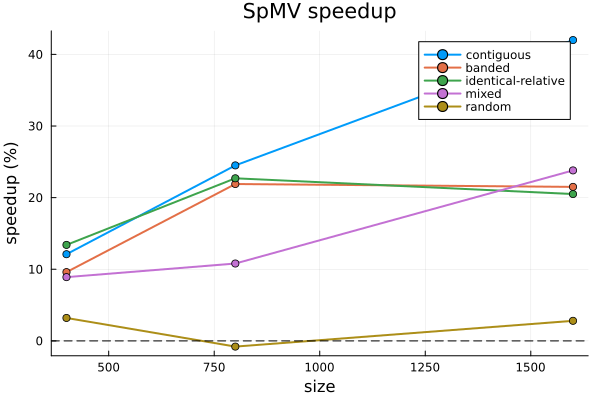

In [19]:
spmv_rows = collect_rows("spmv", results["spmv"])
print_csv(spmv_rows)
print_judgments("SpMV", results["spmv"])
plot_speedup(spmv_rows; title="SpMV speedup")

## SpMM results

This cell prints the raw SpMM benchmark numbers as CSV, then prints BenchmarkTools judgments, and then plots SpMM speedup against size for each pattern.

op,size,pattern,generic_min_ns,specialized_min_ns,generic_median_ns,specialized_median_ns,speedup_pct
spmm,200,contiguous,618444.000,498634.000,633576.500,505289.000,19.4
spmm,200,banded,71385.000,60388.000,72566.000,60865.000,15.4
spmm,200,identical-relative,59834.000,45624.000,60952.000,47165.000,23.7
spmm,200,mixed,178545.000,146004.000,180731.500,147815.000,18.2
spmm,200,random,16293.000,13966.000,16895.500,14772.000,14.3
spmm,400,contiguous,4752455.000,4110166.000,4798123.500,4148028.000,13.5
spmm,400,banded,514855.000,466550.000,525796.000,472127.500,9.4
spmm,400,identical-relative,244494.000,187817.000,247860.000,196349.000,23.2
spmm,400,mixed,1293764.000,1129257.000,1308188.000,1151104.000,12.7
spmm,400,random,96447.000,89162.000,99208.000,91845.000,7.6
spmm,800,contiguous,41649078.000,33890436.000,44820721.000,34102973.000,18.6
spmm,800,banded,4457876.000,3441018.000,4532205.000,3519912.000,22.8
spmm,800,identical-relative,1012089.000,747860.000,1036690.000,787717.000,26.1
spm

3-element BenchmarkTools.BenchmarkGroup:
  tags: []
  200 => 5-element BenchmarkTools.BenchmarkGroup:
	  tags: []
	  "random" => TrialJudgement(-14.28% => improvement)
	  "identical-relative" => TrialJudgement(-23.75% => improvement)
	  "mixed" => TrialJudgement(-18.23% => improvement)
	  "banded" => TrialJudgement(-15.41% => improvement)
	  "contiguous" => TrialJudgement(-19.37% => improvement)
  800 => 5-element BenchmarkTools.BenchmarkGroup:
	  tags: []
	  "random" => TrialJudgement(-4.36% => invariant)
	  "identical-relative" => TrialJudgement(-26.11% => improvement)
	  "mixed" => TrialJudgement(-21.64% => improvement)
	  "banded" => TrialJudgement(-22.81% => improvement)
	  "contiguous" => TrialJudgement(-18.63% => improvement)
  400 => 5-element BenchmarkTools.BenchmarkGroup:
	  tags: []
	  "random" => TrialJudgement(-7.55% => improvement)
	  "identical-relative" => TrialJudgement(-23.18% => improvement)
	  "mixed" => TrialJudgement(-12.72% => improvement)
	  "banded" => TrialJud

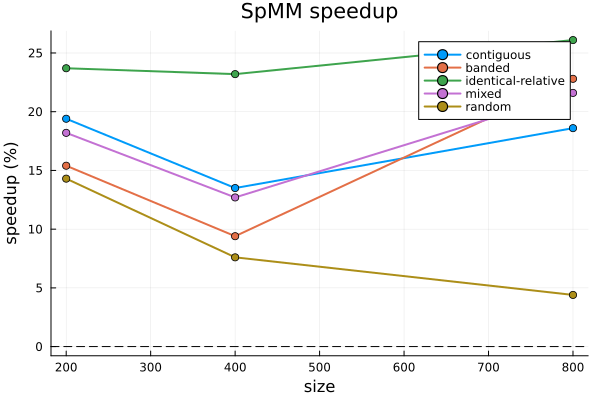

In [20]:
spmm_rows = collect_rows("spmm", results["spmm"])
print_csv(spmm_rows)
print_judgments("SpMM", results["spmm"])
plot_speedup(spmm_rows; title="SpMM speedup")

## Combined CSV

This cell prints the full combined table for both SpMV and SpMM.

In [18]:
all_rows = vcat(spmv_rows, spmm_rows)
print_csv(all_rows)

op,size,pattern,generic_min_ns,specialized_min_ns,generic_median_ns,specialized_median_ns,speedup_pct
spmv,400,contiguous,45900.000,40351.000,48808.000,41890.000,12.1
spmv,400,banded,5028.000,4544.000,5399.000,4633.000,9.6
spmv,400,identical-relative,2201.000,1905.000,2287.000,2010.000,13.4
spmv,400,mixed,12452.000,11347.000,13341.000,11511.000,8.9
spmv,400,random,814.000,788.000,861.000,826.000,3.2
spmv,800,contiguous,222009.000,167518.000,225783.500,170592.000,24.5
spmv,800,banded,21490.000,16773.000,21844.000,17415.000,21.9
spmv,800,identical-relative,4765.000,3684.000,4923.000,3935.000,22.7
spmv,800,mixed,47361.000,42269.000,49993.000,43345.000,10.8
spmv,800,random,2702.000,2724.000,2826.000,2871.000,-0.8
spmv,1600,contiguous,1442848.000,837258.000,1697168.000,862946.000,42.0
spmv,1600,banded,81180.000,63692.000,84429.500,66277.500,21.5
spmv,1600,identical-relative,9591.000,7621.000,9917.000,8134.000,20.5
spmv,1600,mixed,223091.000,169969.000,229747.000,175187.000,23.8
spmv,1600,ra